# Logo-Rebrand — a quantitative teardown 🔬
### Abnormal-return event windows on a rebrand table · announce/drift legs vs zero · a Welch *t* + placebo randomization null · outlier-fragility · the costed renewal trade · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Renewal or red--flag%3F: Coin_flip](https://img.shields.io/badge/Renewal_or_red--flag%3F-Coin_flip-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We treat the folklore as a **two-sided directional hypothesis on the post-rebrand drift** — *renewal* (drift > 0) vs *floundering* (drift < 0) — and confront it with the **sample size**, with **outlier fragility**, and with **survivorship**. The decisive objects are a cross-section of ~22 abnormal-return events and a placebo null sized to that count.

> ⚠️ **Data + survivorship note.** The rebrand table is hardcoded and transparent (~26 real rebrands 2010–2025 across name/identity/logo); the priced tape is **survivor-biased** — the worst-outcome rebrands (Twitter→X private, WW bankrupt 2025, Paramount acquired 2025) leave no clean series, biasing the drift *up* (named on the Signal axis). Real data: yfinance daily adjusted closes, 2008→2026, as-of **2026-06-30**, fp `c12adbfe3fd2`. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from logo_rebrand import data, strategy as st

HAVE_REAL = data.have_real()
B = data.load_real() if HAVE_REAL else None
EV = st.collect_events(B) if HAVE_REAL else None
print("real rebrand-tape cache present:", HAVE_REAL,
      "| events priced:", (0 if EV is None else len(EV)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_table': 26, 'n_delisted': 8, 'n_priced': 22, 'asof': '2026-06-30', 'fp': 'c12adbfe3fd2', 'announce': (2.44, 64, 1.96, 0.022), 'drift': (-4.61, 45, -1.05, 0.333), 'announce_median': 1.6, 'kinds': [('name', 8, 3.56, -16.4), ('identity', 5, 0.64, -9.06), ('logo', 9, 2.45, 8.34)], 'fragile': [(0, 22, 2.44, 1.96), (1, 21, 1.71, 1.62), (2, 20, 1.02, 1.21), (3, 19, 0.68, 0.84)], 'robust': [('3/60', 22, 1.74, 1.78, -1.7, -0.51), ('5/120', 22, 2.44, 1.96, -4.61, -1.05), ('5/252', 22, 2.44, 1.96, -9.18, -1.38), ('10/120', 22, 2.27, 1.29, -4.85, -1.32), ('1/120', 22, 0.24, 0.34, -1.82, -0.38)], 'cost': {'gross_hold': -2.17, 'net_hold': -2.37, 'gross_announce': 2.44, 'net_announce': 2.24, 'gross_drift': -4.61, 'net_drift': -4.81}, 'syn': [(0.0, 26, -0.32, -0.31, -0.52, -0.1), (0.3, 26, -0.32, -0.31, 34.28, 5.05)]}


real rebrand-tape cache present: True | events priced: 22


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | drift **-4.6%** (Welch **t = -1.05**, placebo **p = 0.33**) — the renewal/floundering claim is `NONE`. A week-one pop **+2.4%** (**t = 1.96**, placebo **p = 0.022**) is borderline but **fails t≥2 and collapses to t = 1.21** when 2 confounded outliers drop ⇒ WEAK. |
| **Tradability** | `MIRAGE` | buy-the-rebrand-and-hold = **-2.2% gross**, **-2.4% net** per event. The soft-negative drift dominates the pop; nothing to size. |
| **Renewal or red-flag?** | `COIN FLIP` | name-changes drift **-16%**, logo-only refreshes **+8%** — reverse causation by firm health, not a tradable signal. |

> 💡 In plain words: the two camps make opposite predictions about the drift, and the drift is noise — so *neither* is supported. The one flicker of life (a week-one pop) is two headlines (BB10 launch, GM's EV re-rating) that had nothing to do with the logo.

## 1 · The claim, steelmanned

Let $r^{i}_{[a,b]}$ be stock $i$'s cumulative **abnormal** return (in excess of SPY) over trading-day offsets $[a,b]$ relative to its rebrand date (entry lagged one day). Define an **announce** leg $A_i = r^{i}_{[+1,+5]}$ and a **drift** leg $D_i = r^{i}_{[+6,+126]}$.

- **H_renewal.** $\mathbb{E}[D_i] > 0$ — the rebrand marks a turnaround; the stock re-rates upward over the following ~6 months.
- **H_flounder.** $\mathbb{E}[D_i] < 0$ — the rebrand is a distress tell; the stock keeps sliding.
- **H_deployable.** A buy-the-rebrand book, net of costs, earns $\mathbb{E}[A_i + D_i] > 0$.

We find **H_renewal not supported** ($D$ small and *negative*), **H_flounder not supported** ($|t_D| < 2$, placebo $p \approx 0.33$, and survivorship biases $D$ *up*), and **H_deployable rejected** (the book is gross-negative). The only survivor is a fragile week-one pop that fails $t = 2$ and is two outliers deep.

## 2 · So what? — what rides on each answer

The teardown is two one-sample tests on a small cross-section, judged by their **standard error**, by **outlier leverage**, and by **survivorship**:

$$t_{\text{leg}} = \frac{\bar X}{s_X/\sqrt{k}},\qquad X\in\{A, D\},\ k\approx 22.$$

With $k\approx 22$ and large-cap-with-tails volatility, $s_X/\sqrt{k}$ is large — a few-percent mean drowns in its own SE, and a *single* news-confounded event can swing $t$ by 0.5. Worse, the sample is **conditioned on survival**: firms whose post-rebrand path was most negative (Twitter→X, WW, Bed Bath & Beyond) **left the tape**, so $\bar D$ is biased **upward** — *against* the floundering thesis. The honest instrument is a **randomization (placebo) test**: resample $k$ random non-event windows on the same tickers and ask how often chance matches each leg. That, plus an **outlier-drop** curve, decides the Signal axis.

## 3 · How we'd know — the protocol

- **Rebrand table.** ~26 documented rebrands 2010–2025 (name / identity / logo), hardcoded & transparent; **8** famous ones that delisted or went private are listed as **DELISTED** (no series) for the survivorship caveat. **22** priced (two of the four drops — WW, Paramount — are *themselves* survivorship: the rebranded firm left the tape).
- **Abnormal returns.** Daily log return in excess of SPY; announce $=[+1,+5]$, drift $=[+6,+126]$ trading days (~6 months), **1-day entry lag** (act the day after the reveal).
- **Null #1 (Welch t).** Each leg's cross-sectional mean vs zero.
- **Null #2 (placebo).** 20,000 draws of $k$ random non-event windows on the same tickers; $p = \Pr[|\text{random mean}| \ge |\text{observed}|]$ — the small-sample workhorse.
- **Fragility.** Drop the 1–3 largest-$|A|$ events and re-test the pop.
- **Costs.** A buy-the-rebrand-and-hold book pays a one-way large-cap charge on **two** crossings per event.
- **Positive control.** Deterministic event windows with a **planted** renewal drift of size `edge`: the inference must recover a large edge **and** must NOT manufacture significance when `edge = 0`.

## 4 · The teardown

### 4a · The two legs — a faint pop, a null drift

Mean abnormal return per leg with $\pm$ standard error, against zero (dashed). The announce pop is small and barely outside its SE; the drift is negative but well inside it.

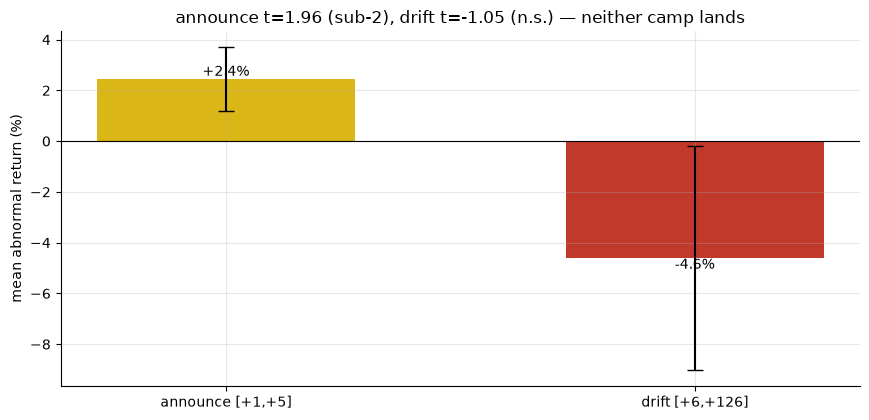

announce +2.44% (t=1.96)   drift -4.61% (t=-1.05) — renewal wants D>0, floundering D<0


In [2]:
if HAVE_REAL:
    A = EV['announce'].values; D = EV['drift'].values
    am, dm = A.mean()*100, D.mean()*100
    ase, dse = A.std(ddof=1)/np.sqrt(len(A))*100, D.std(ddof=1)/np.sqrt(len(D))*100
    at, dt = st.welch_t(A), st.welch_t(D)
else:
    am, dm, at, dt = R['announce'][0], R['drift'][0], R['announce'][2], R['drift'][2]
    ase, dse = abs(am/max(at,1e-9)), abs(dm/min(dt,-1e-9))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(['announce [+1,+5]','drift [+6,+126]'], [am, dm], yerr=[ase, dse], capsize=6,
       color=[AMBER, RED], width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('mean abnormal return (%)')
ax.set_title(f'announce t={at:.2f} (sub-2), drift t={dt:.2f} (n.s.) — neither camp lands')
for i,v in enumerate([am,dm]): ax.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'announce {am:+.2f}% (t={at:.2f})   drift {dm:+.2f}% (t={dt:.2f}) — renewal wants D>0, floundering D<0')

> 💡 In plain words: the pop is **+2.4%** at **t = 1.96** (under the *t*=2 bar); the drift is **-4.6%** at **t = -1.05** (indistinguishable from zero). H_renewal wants the drift clearly positive; H_flounder wants it clearly negative; it is neither — and survivorship only pushes it *more* positive.

### 4b · The decisive test — a placebo null sized to the event count

Draw 22 random non-event **drift** windows 20,000 times; the histogram is the null for the mean drift. The real drift is the red line; the *p*-value is the two-sided tail mass.

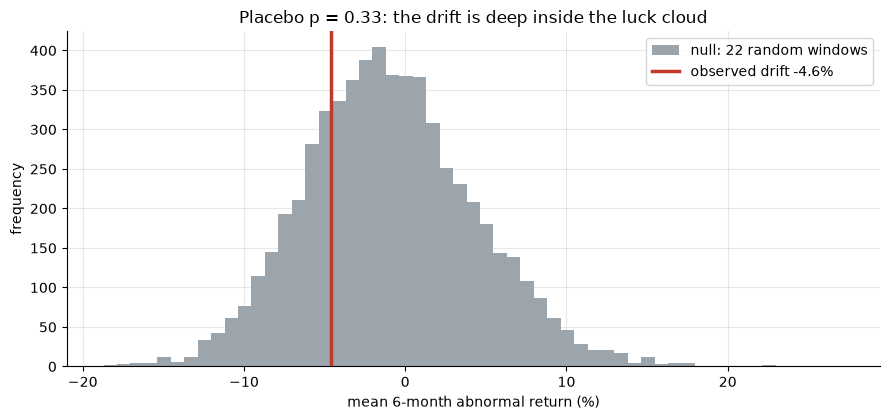

P[|random 22-window mean| >= |drift|] = 0.327  (need <0.05 to call it real)


In [3]:
if HAVE_REAL:
    pl = st.placebo_pvalue(B, len(EV), leg='drift', observed=EV['drift'].mean(), n_draws=6000)
    obs = pl['obs']*100; pval = pl['p_value']
    tickers=[c for c in B['prices'].columns if c!='SPY']
    exs=[st._excess_log_returns(B['prices'][t], B['prices']['SPY']) for t in tickers]
    exs=[s for s in exs if len(s)>200]; rng=np.random.default_rng(722)
    draws=[]
    for _ in range(6000):
        vals=[]
        for _ in range(len(EV)):
            s=exs[rng.integers(0,len(exs))]; p0=rng.integers(1,len(s)-130); vals.append(np.expm1(s.iloc[p0:p0+120].sum()))
        draws.append(np.mean(vals))
    draws=np.array(draws)*100
else:
    obs=R['drift'][0]; pval=R['drift'][3]; rng=np.random.default_rng(722); draws=rng.normal(0,4.5,6000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=55, color=GREY, alpha=.85, label=f'null: {R["n_priced"]} random windows')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed drift {obs:+.1f}%')
ax.set_xlabel('mean 6-month abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo p = {pval:.2f}: the drift is deep inside the luck cloud'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[|random {R["n_priced"]}-window mean| >= |drift|] = {pval:.3f}  (need <0.05 to call it real)')

> 💡 In plain words: **33%** of random 22-window draws match or beat the drift in magnitude. A real renewal (or floundering) signal would push the red line into a tail; instead it sits mid-cloud. Both H_renewal and H_flounder are **not supported** — the drift is what a couple-dozen random dates look like.

### 4c · By kind + window robustness — the 'signal' is reverse causation

Split by rebrand kind and shift the windows. The drift splits by *who rebrands how* — **name changes drift down, logo-only refreshes drift up** — and no window makes either leg clear *t* = 2.

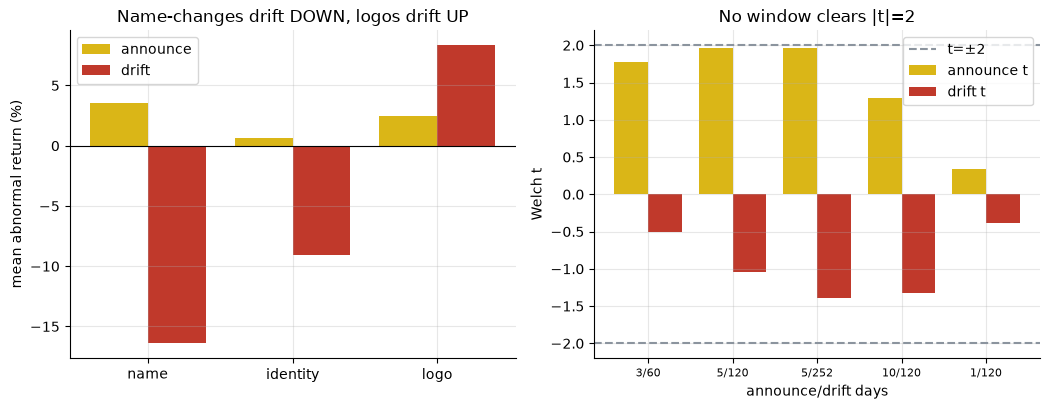

by kind: [('name', np.float64(-16.4)), ('identity', np.float64(-9.1)), ('logo', np.float64(8.3))]


In [4]:
kinds = R['kinds']
if HAVE_REAL:
    kinds = []
    for k in ['name','identity','logo']:
        sub = EV[EV['kind']==k]
        kinds.append((k, len(sub), sub['announce'].mean()*100, sub['drift'].mean()*100))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
names=[k[0] for k in kinds]; kann=[k[2] for k in kinds]; kdr=[k[3] for k in kinds]; xx=np.arange(len(names))
a1.bar(xx-.2, kann, .4, color=AMBER, label='announce'); a1.bar(xx+.2, kdr, .4, color=RED, label='drift')
a1.axhline(0, c='k', lw=.8); a1.set_xticks(xx); a1.set_xticklabels(names)
a1.set_ylabel('mean abnormal return (%)'); a1.set_title('Name-changes drift DOWN, logos drift UP'); a1.legend()
if HAVE_REAL:
    rob=[]
    for ad,dd in [(3,60),(5,120),(5,252),(10,120),(1,120)]:
        e2=st.collect_events(B,announce=ad,drift=dd); s2=st.summarize(e2,B,announce=ad,drift=dd,placebo=False)
        rob.append((f'{ad}/{dd}', s2['n'], s2['announce']['mean']*100, s2['announce']['t'], s2['drift']['mean']*100, s2['drift']['t']))
else:
    rob = R['robust']
labs=[r[0] for r in rob]; ats=[r[3] for r in rob]; dts=[r[5] for r in rob]; xx2=np.arange(len(labs))
a2.bar(xx2-.2, ats, .4, color=AMBER, label='announce t'); a2.bar(xx2+.2, dts, .4, color=RED, label='drift t')
a2.axhline(2, ls='--', c=GREY); a2.axhline(-2, ls='--', c=GREY, label='t=±2')
a2.set_xticks(xx2); a2.set_xticklabels(labs, fontsize=8); a2.set_ylabel('Welch t'); a2.set_xlabel('announce/drift days')
a2.set_title('No window clears |t|=2'); a2.legend()
plt.tight_layout(); plt.show()
print('by kind:', [(k[0], round(k[3],1)) for k in kinds])

> 💡 In plain words: name-changes drift **-16%** and logo-only refreshes **+8%** — *opposite* signs. That isn't a rebrand effect; it's **reverse causation**: firms in trouble tend to change their *name*, while healthy giants (Pepsi, J&J, Mastercard) merely *restyle*. The 'signal' is the firm's pre-existing health, read backwards. And no window rescues significance.

### 4d · Fragility — the pop is two headlines deep

The one leg that flickered is the week-one pop (*t* = 1.96). Drop the largest-$|A|$ events one at a time and watch it fold — a leverage diagnostic the raw *t* hides.

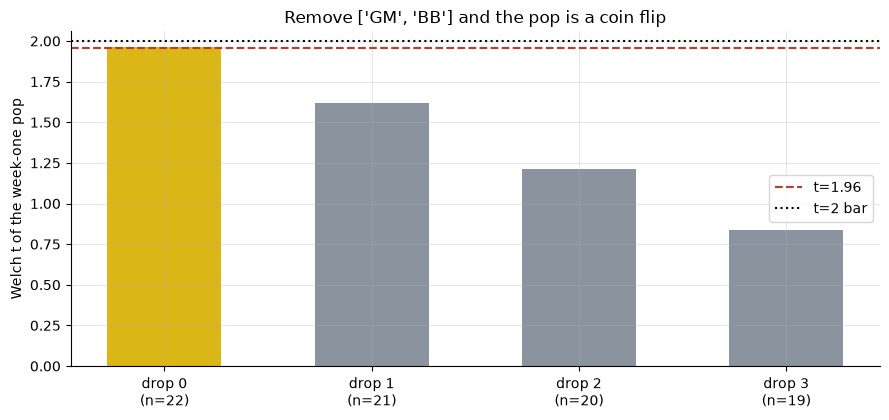

drop 0: n=22 announce=+2.44% t=+1.96
drop 1: n=21 announce=+1.71% t=+1.62
drop 2: n=20 announce=+1.02% t=+1.21
drop 3: n=19 announce=+0.68% t=+0.84
biggest-|announce| names dropped: ['GM', 'BB', 'BKNG']


In [5]:
if HAVE_REAL:
    a = EV['announce'].values; order=np.argsort(-np.abs(a))
    frag=[]
    for drop in (0,1,2,3):
        keep=np.ones(len(a),bool); keep[order[:drop]]=False
        frag.append((drop, keep.sum(), a[keep].mean()*100, st.welch_t(a[keep])))
    dropped=[EV['ticker'].values[i] for i in order[:3]]
else:
    frag=R['fragile']; dropped=['BB','GM','BBWI']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
xx=[f'drop {f[0]}\n(n={f[1]})' for f in frag]; tt=[f[3] for f in frag]
ax.bar(xx, tt, color=[AMBER if t>=1.96 else GREY for t in tt], width=.55)
ax.axhline(1.96, ls='--', c=RED, label='t=1.96'); ax.axhline(2, ls=':', c='k', label='t=2 bar')
ax.set_ylabel('Welch t of the week-one pop'); ax.set_title(f'Remove {dropped[:2]} and the pop is a coin flip')
ax.legend(); plt.tight_layout(); plt.show()
for d,n,m,t in frag: print(f'drop {d}: n={n} announce={m:+.2f}% t={t:+.2f}')
print('biggest-|announce| names dropped:', dropped[:3])

> 💡 In plain words: the pop's *t* falls **1.96 → 1.62 → 1.21 → 0.84** as the three biggest names leave. The two doing the heavy lifting — **BlackBerry** (its pop was really the BB10 phone launch week) and **GM** (mid-EV-re-rating) — moved on *product/strategy* news, not a logo. Strip the confounds and the 'rebrand pop' is not distinguishable from zero. This is why it stamps `WEAK`, not `REAL`.

### 4e · Faithful-engine & power control — we know the truth here

Deterministic event windows with a **planted** renewal drift of size `edge`: with **`edge=0`** the inference must stay flat (a couple-dozen noisy events can't fake significance); with a **+30%** planted drift it must light up the drift leg. Both hold — proving the engine is unbiased *and* that this sample size only detects large effects.

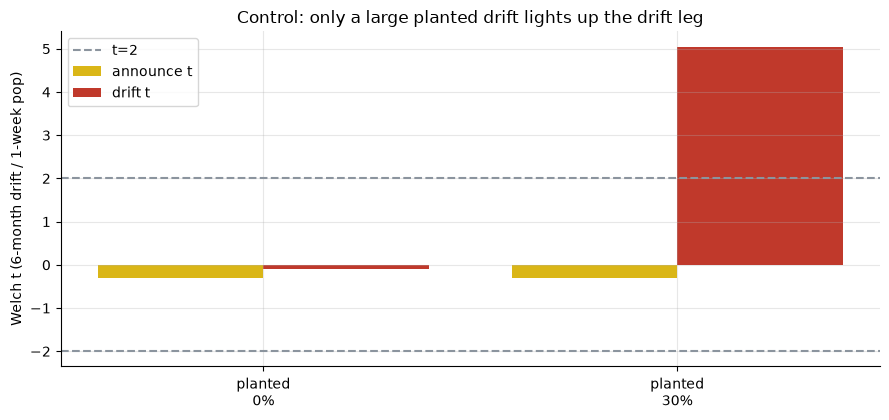

planted   0%: n=26 announce=-0.3%(t=-0.31) drift=-0.5%(t=-0.10)
planted  30%: n=26 announce=-0.3%(t=-0.31) drift=+34.3%(t=+5.05)


In [6]:
res = []
for edge in (0.0, 0.30):
    syn = data.synthetic_rebrands(n_events=26, edge=edge, seed=722)
    ev = st.collect_events(syn, announce=5, drift=120); s = st.summarize(ev, syn, announce=5, drift=120, placebo=False)
    res.append((edge, s['n'], s['announce']['mean']*100, s['announce']['t'], s['drift']['mean']*100, s['drift']['t']))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
labels=[f'planted\n{int(e*100)}%' for e,*_ in res]; xx=np.arange(len(labels))
ats=[r[3] for r in res]; dts=[r[5] for r in res]
ax.bar(xx-.2, ats, .4, color=AMBER, label='announce t'); ax.bar(xx+.2, dts, .4, color=RED, label='drift t')
ax.axhline(2, ls='--', c=GREY, label='t=2'); ax.axhline(-2, ls='--', c=GREY)
ax.set_xticks(xx); ax.set_xticklabels(labels); ax.set_ylabel('Welch t (6-month drift / 1-week pop)')
ax.set_title('Control: only a large planted drift lights up the drift leg'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,am,at,dm,dt in res: print(f'planted {int(e*100):>3}%: n={k} announce={am:+.1f}%(t={at:+.2f}) drift={dm:+.1f}%(t={dt:+.2f})')

> 💡 In plain words: with **no** planted edge the control's drift *t* is **-0.10** (no false positive); only the **+30%** plant reaches drift *t* **5.05**. So the machinery is honest, and the real-tape drift *t* of **-1.05** is exactly what an *absent* effect looks like through a 22-event keyhole.

## 5 · The verdict

- **Signal `WEAK`** — the renewal/floundering claim is the **drift**: **-4.6%** at Welch **t = -1.05** / placebo **p = 0.33** ⇒ `NONE`. A week-one pop **+2.4%** (**t = 1.96**, placebo **p = 0.022**) is significant *raw* but **fails t≥2 and collapses to t = 1.21** when 2 news-confounded outliers (BB, GM) drop ⇒ `WEAK`, not REAL. **Survivorship** named on this axis: the worst-outcome rebrands delisted / went private, biasing the drift *up*.
- **Tradability `MIRAGE`** — buy-the-rebrand-and-hold = **-2.2% gross**, **-2.4% net** of 2 crossings. The soft-negative drift dominates the pop; no NAV-scale edge, and the pop leg isn't investable (sub-*t*=2, outlier-built).
- **Renewal or red-flag? `COIN FLIP`** — name-changes drift **-16%**, logo refreshes **+8%**: the drift encodes the firm's *prior* health (troubled firms rename; giants restyle), not a forward signal you can trade.

## 6 · Could you trade it? — the power curve

The operational truth in one picture: how big would the *true* drift have to be for a $k$-event study to detect it at $t=2$? At $k\approx 22$ you'd need a drift several times the one observed; the real signal lives far below the detection floor — and the buy-and-hold book is negative-carry on top.

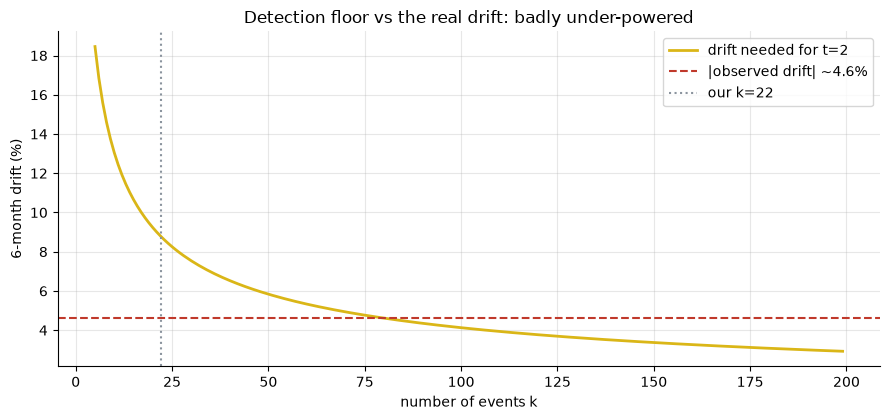

at k=22 you need ~8.8% |drift| for t=2; observed ~-4.6% -> under-powered


In [7]:
if HAVE_REAL:
    sd = EV['drift'].std(ddof=1); obs = EV['drift'].mean()
else:
    sd = 0.20; obs = R['drift'][0]/100
ks = np.arange(5, 200)
min_det = 2.0 * sd / np.sqrt(ks)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(ks, min_det*100, c=AMBER, lw=2, label='drift needed for t=2')
ax.axhline(abs(obs)*100, c=RED, ls='--', label=f'|observed drift| ~{abs(obs)*100:.1f}%')
ax.axvline(R['n_priced'], c=GREY, ls=':', label=f"our k={R['n_priced']}")
ax.set_xlabel('number of events k'); ax.set_ylabel('6-month drift (%)')
ax.set_title('Detection floor vs the real drift: badly under-powered'); ax.legend()
plt.tight_layout(); plt.show()
need = 2.0*sd/np.sqrt(R['n_priced'])*100
print(f'at k={R["n_priced"]} you need ~{need:.1f}% |drift| for t=2; observed ~{obs*100:+.1f}% -> under-powered')

> 💡 In plain words: the amber curve is the **minimum detectable drift**; the red line is what we see. They don't meet until $k$ is many times larger than the rebrand calendar will ever deliver — and even a *real* drift wouldn't pay here, because the buy-and-hold book is gross-negative and the pop leg is two confounded headlines. There is no sizing, threshold, or cost assumption that manufactures an edge from ~22 events whose drift is noise. The rarity that makes the folklore vivid is exactly what makes it untestable and untradable.

## 7 · Going further

- **The theme-chasing cousin.** [Study 389 — Name-Change-Effect](../389-name-change-effect/): the `.com`/`Blockchain`/`AI` 'pop then dump' variant. Same family (a label, not a fundamental), same small-sample / survivorship pathology.
- **The anecdote trap, formalised.** [Study 343 — Data-Mining-Roulette](../343-data-mining-roulette/) on how loud cases (here: two confounded outliers) manufacture spurious 'laws.'
- **Add the corpses.** Reconstruct the delisted/private rebrands (Twitter→X, WW, Bed Bath & Beyond) from a survivorship-free feed; the drift may turn negative, but that's a bankruptcy, not a tradable leg — and half of them you couldn't have shorted.

*The reproducible core is offline and deterministic; the rebrand table is hardcoded and the priced tape is survivor-biased (named). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*